In [1]:
from learning_in_games import *

In [52]:
n_agents = 2
n_states = 2
n_actions = 2

rewards_payoff = 0.5
suckers_payoff = 0.5
gameConfig = PrisonersDilemmaConfig(n_agents, n_actions, n_states, rewards_payoff, suckers_payoff)

alpha = 0.8
alpha_imitation = 0.
gamma = 0
qinit = "UNIFORM"
epsilon = 0.5 # "DECAYED"
imitation = False

agentConfig = EpsilonGreedyConfig(alpha, gamma, qinit, epsilon)
imitationAgentConfig = EpsilonGreedyConfig(alpha_imitation, gamma, qinit, epsilon)

name = f"pd_experiment"

In [53]:
n_iter = 100

In [60]:
Q.argmax(axis=2)

array([[0, 1],
       [0, 1]])

In [61]:
Q

array([[[-1.37919443, -1.97893203],
        [-0.46799744,  0.00768213]],

       [[-1.05763685, -1.98123501],
        [-0.46768002,  0.03206193]]])

In [41]:
def prisoners_recommender(Q):
    ind = np.arange(2)
    argmaxQ = Q.argmax(axis=2)
    if np.any(argmaxQ[0] == 0) and np.any(argmaxQ[1] == 0):
        # both players can cooperate
        q_diff = Q[ind, ind, 0] - Q[ind, ind, 1]
        

In [59]:
Q = initialize_q_table(qinit, n_agents, n_states, n_actions, qmin=-2, qmax=-1)
exp_start, exp_end, exp_decay = initialize_exploration_rates(n_iter, gameConfig, agentConfig)
exp_decay_factor = 8
M = {}
ind = np.arange(gameConfig.n_agents)
S = np.random.randint(gameConfig.n_states, size=gameConfig.n_agents)
S_ = S

for t in range(n_iter):
    agentConfig.epsilon = update_exploration_rates(t, n_iter, exp_start=exp_start, exp_end=exp_end, exp_decay_factor=exp_decay_factor)
    
    A = e_greedy_select_action(Q, S, epsilon)

    R, S_PD = prisoners_dilemma(A, gameConfig)
    # R = np.mean(R)
    
#     S_ = np.where(independent_moving_average > R, 1, 0)
#     S_ = np.ones(shape=(n_agents)).astype(int) if R.mean() < -1.9 else np.zeros((n_agents)).astype(int)
#     S_ = np.ones(shape=(n_agents)).astype(int) if R.mean() > global_moving_average else np.zeros((n_agents)).astype(int)
#     S_ = np.random.randint(n_states, size=n_agents).astype(int)
    
    # print(indices_to_update)
    Q, sum_of_belief_updates = bellman_update_q_table(ind, Q, S, A, R, S_, alpha, gamma)
    
    ## SAVE PROGRESS DATA
    M[t] = {
        "nA": np.bincount(A, minlength=gameConfig.n_actions),
        "R": R,
        "Q": Q[ind, S, A]
    }
    
    S = S_

In [39]:
x_vals = np.arange(0, n_iter, 1)
threshold = 0
W = np.array([M[t]["R"].mean() for t in x_vals])[int(threshold*n_iter):-1]

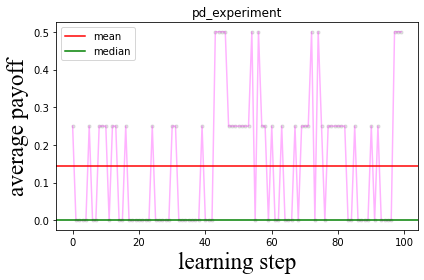

In [40]:
fig, ax = plt.subplots()
# ax.axhline(y=2.0, ls="--")
# ax.axhline(y=1.5, ls="--")
plt.plot(x_vals, [M[t]["R"].mean() for t in x_vals], alpha=0.3, color="magenta")
plt.scatter(x_vals, [M[t]["R"].mean() for t in x_vals], alpha=0.1, s=10, c="black")

mean = W.mean()
median = np.median(W)
ax.axhline(y=mean, xmin=threshold, xmax=1,label="mean", color="red")
ax.axhline(y=median, xmin=threshold, xmax=1, label="median", color="green")

plt.title(name)

# plt.ylim(1.5, 2)
plt.xlabel("learning step", fontdict={"font": "Times New Roman", "fontsize": 23})
plt.ylabel("average payoff", fontdict={"font": "Times New Roman", "fontsize": 23})
plt.tight_layout()
plt.legend()
# plt.savefig(f"delay_experiments/braess_timeseries_{name}.png")